In [1]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())


      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [2]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [3]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median())

0        12.99
1        15.10
2        18.53
3        15.80
4        24.52
         ...  
34028    17.42
34029    27.39
34030    18.60
34031    18.60
34032    21.21
Name: mileage_new, Length: 34033, dtype: float64

In [4]:
df["max_power"].fillna(df["max_power"].median())
df["max_torque"].fillna(df["max_torque"].median())

0        200.0
1        330.0
2        113.0
3        151.0
4        200.0
         ...  
34028    320.0
34029    190.0
34030    114.7
34031    114.7
34032    113.0
Name: max_torque, Length: 34033, dtype: float64

In [5]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

In [6]:
import numpy as np

# Define columns to check for outliers
log_cols = ['max_power', 'max_torque', 'max_engine_capacity_new', 'price']

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [7]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])


In [8]:
import numpy as np

features = [
    
 "km_driven", "mileage_new", 
    "log_max_power", "log_max_torque",
 "log_max_engine_capacity_new"

]

df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
y = df["price"]
#y = np.log(df["price"])  # Natural logarithm (base e)

In [9]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


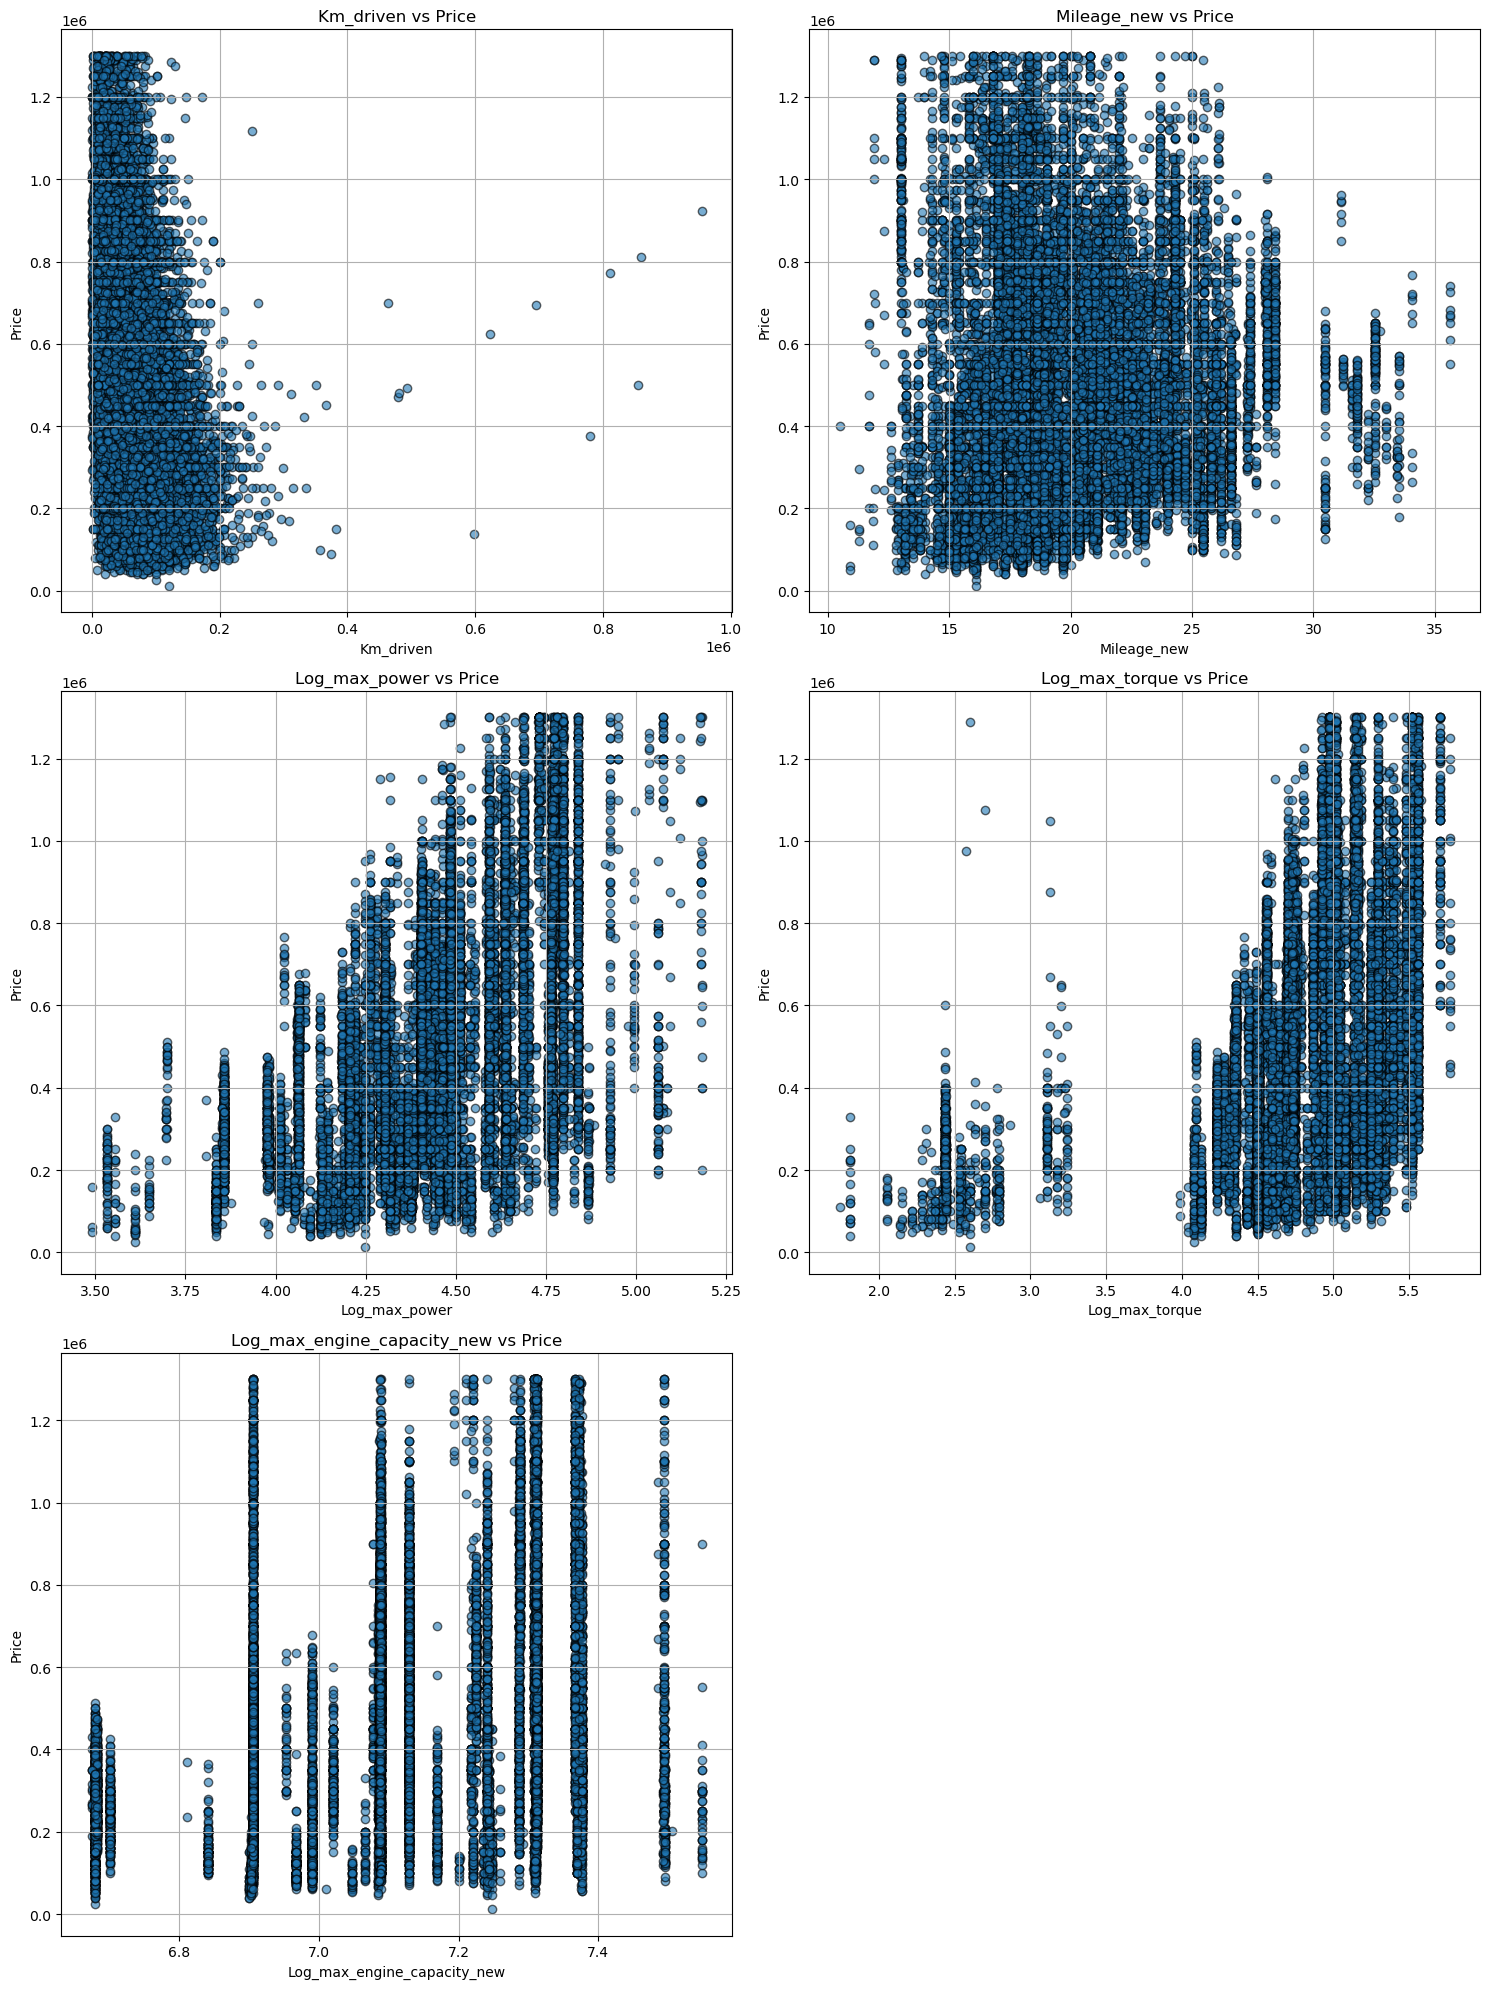

In [11]:
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
variables = ["km_driven", "mileage_new", 
    "log_max_power", "log_max_torque",
 "log_max_engine_capacity_new"]  # Variables to plot
price_column = 'price'  # Target variable
data = df  # Ensure this is a DataFrame


# Plotting scatter plots
plt.figure(figsize=(15, 20))

for i, variable in enumerate(variables, 1):
    plt.subplot(3, 2, i)
    try:
        plt.scatter(data[variable], data[price_column], alpha=0.6, marker='o', edgecolor='k')
        plt.xlabel(variable.capitalize())
        plt.ylabel(price_column.capitalize())
        plt.title(f'{variable.capitalize()} vs {price_column.capitalize()}')
        plt.grid(True)
    except TypeError as e:
        print(f"Could not plot {variable} due to: {e}")

plt.tight_layout()
plt.show()


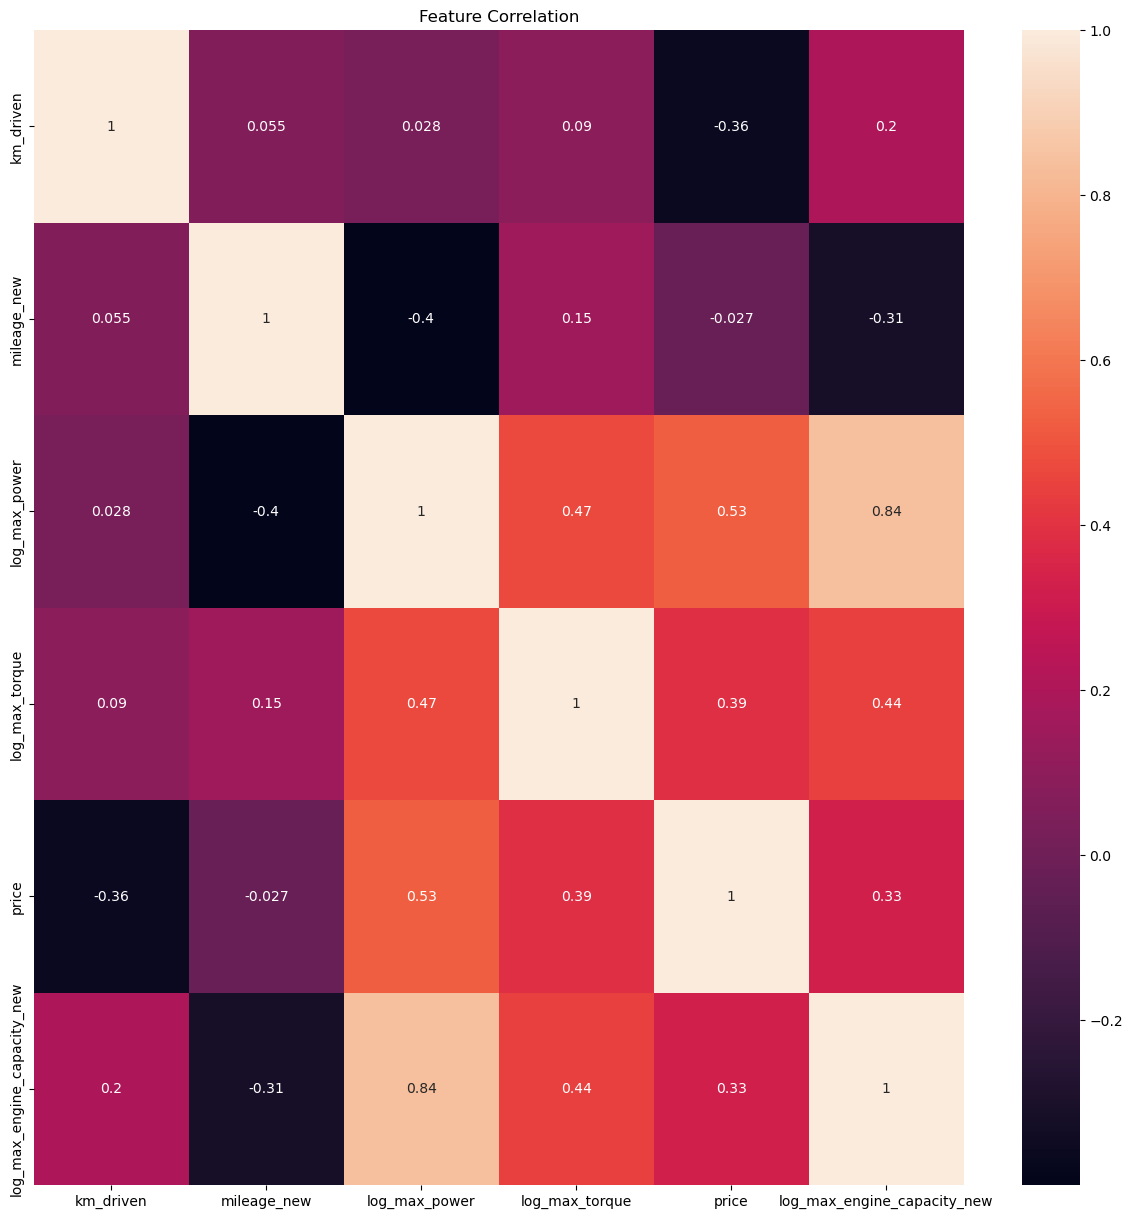

In [12]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

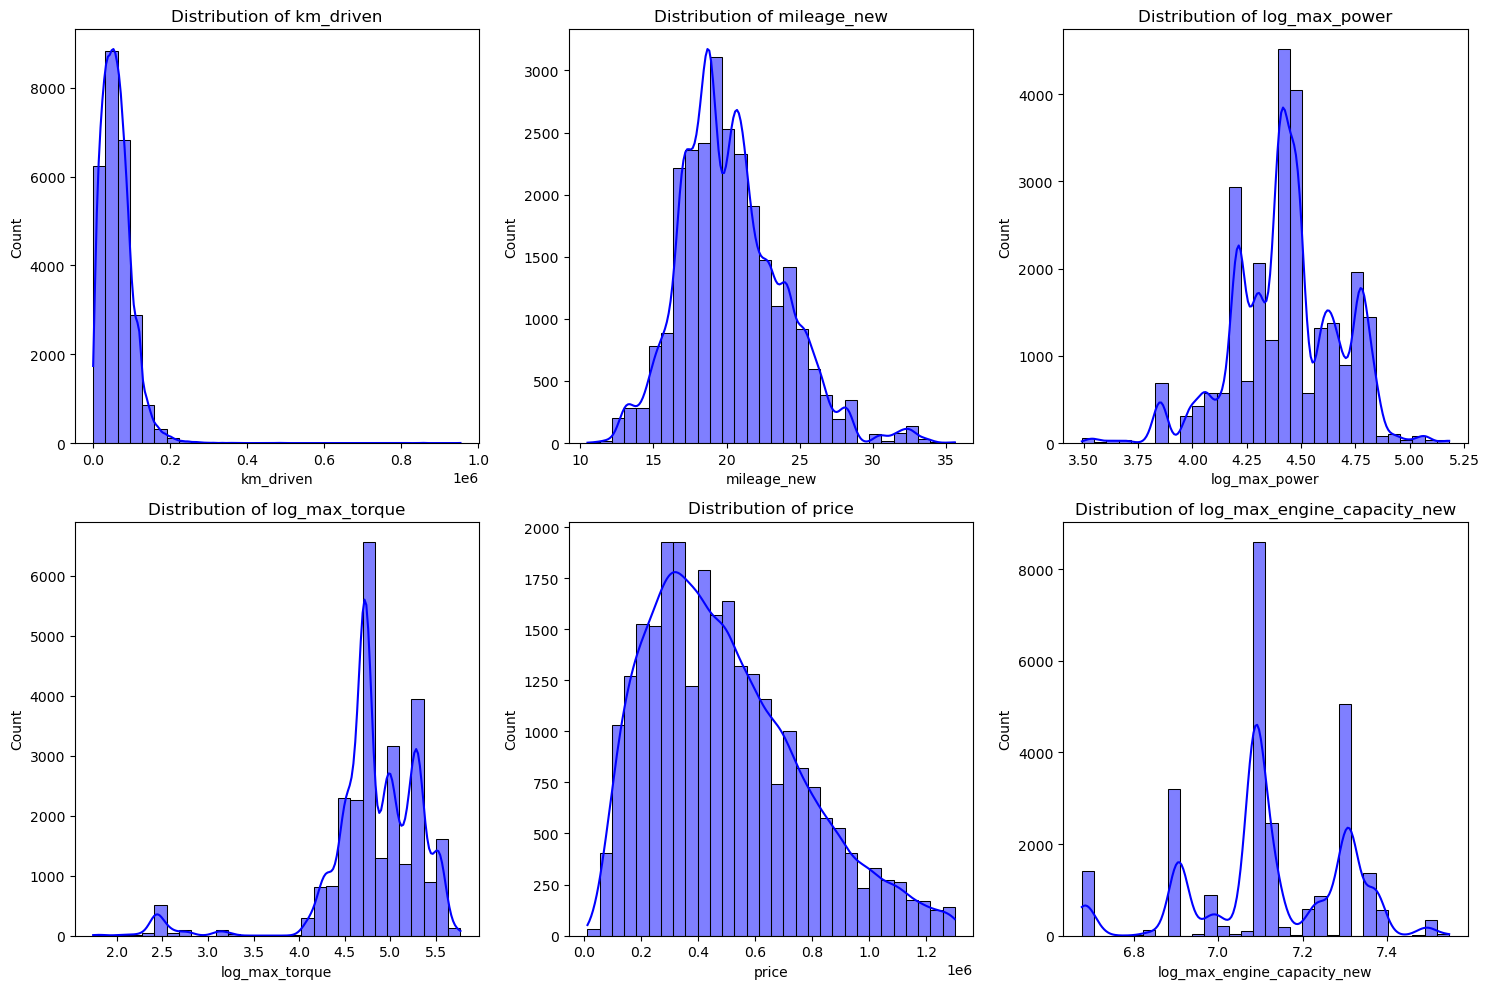

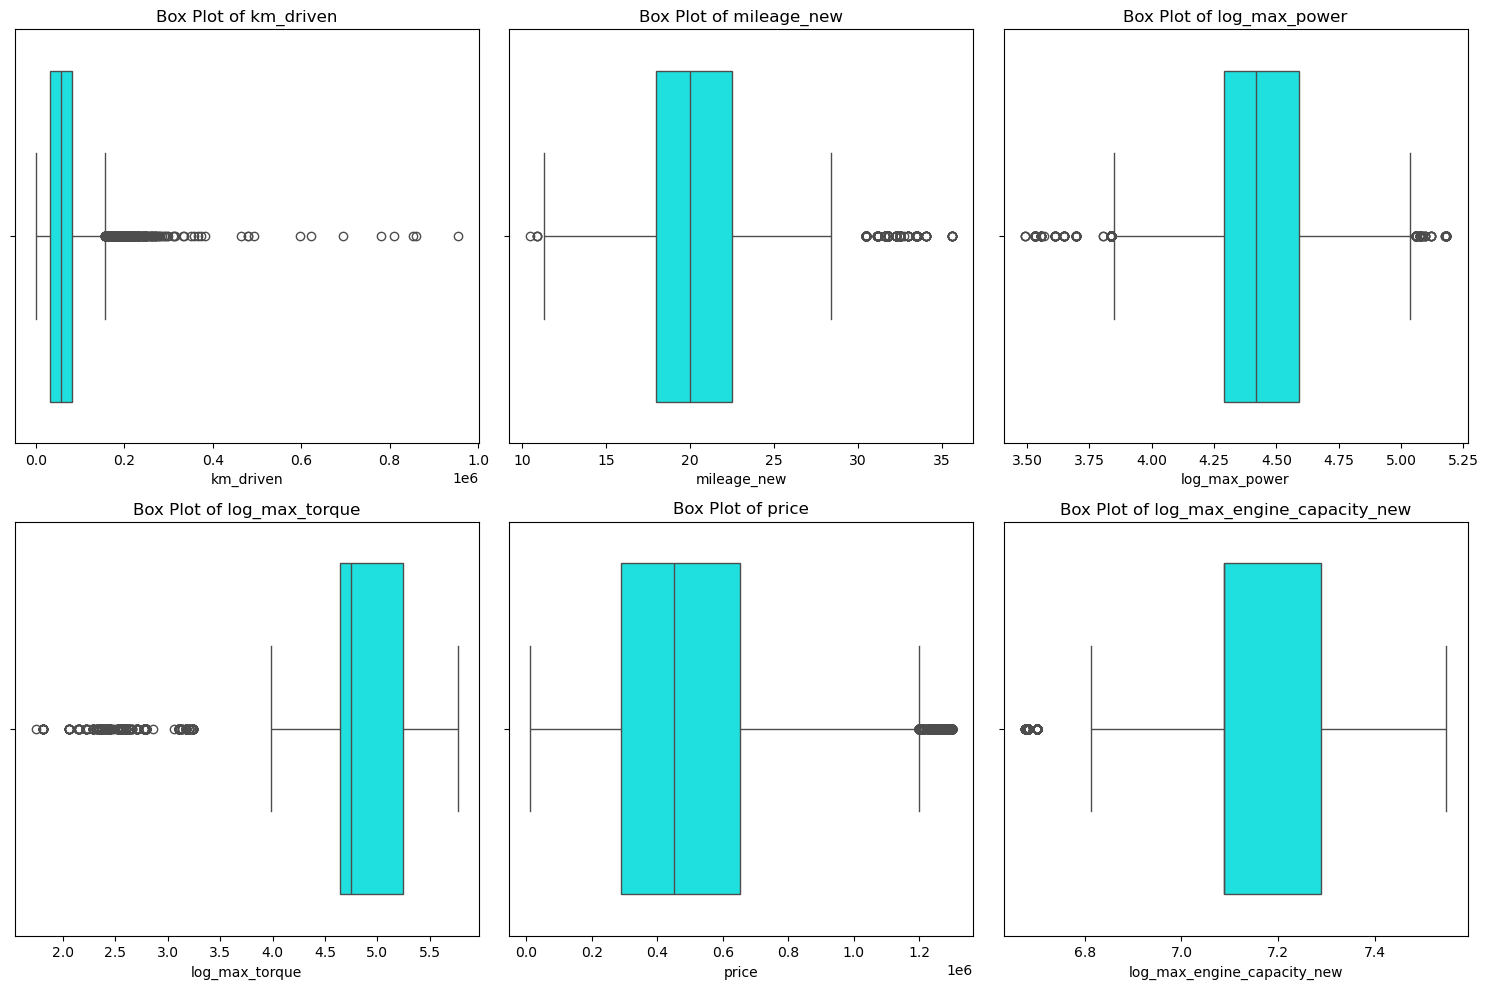

In [13]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 294635077632.0000 - mae: 473020.0000 - val_loss: 68287770624.0000 - val_mae: 200700.5781
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 62329413632.0000 - mae: 199736.2344 - val_loss: 58474233856.0000 - val_mae: 196789.7500
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 58036940800.0000 - mae: 194830.2188 - val_loss: 56139980800.0000 - val_mae: 192103.1719
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 55884566528.0000 - mae: 190593.0156 - val_loss: 53928353792.0000 - val_mae: 188267.9062
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 52910522368.0000 - mae: 185750.8125 - val_loss: 51431743488.0000 - val_mae: 183290.5938
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 51667021824.0000 - mae: 183253.2344 - val_loss: 48591327232.0000 - val_mae: 176498.2188
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 47668588544.0000 - mae: 175095.8281 - val_loss: 452

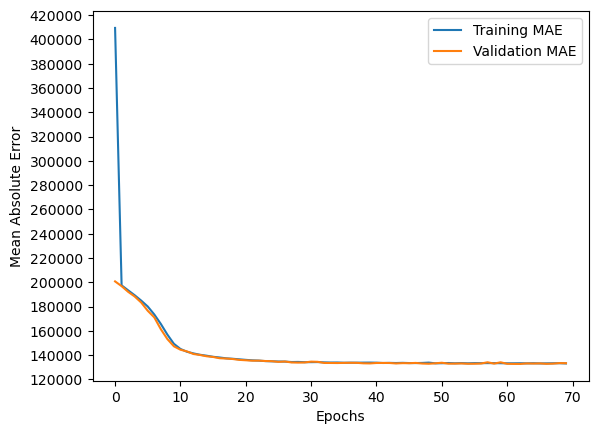

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model10 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.01),
    Dense(128, activation="relu"),
    Dropout(0.01),
    Dense(128, activation="relu"),
    Dropout(0.01),
    Dense(1)
])
model10.summary()
model10.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model10.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 293859393536.0000 - mae: 469024.9375 - val_loss: 61134786560.0000 - val_mae: 197138.0781
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 61656387584.0000 - mae: 200411.1719 - val_loss: 58285924352.0000 - val_mae: 193630.0469
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 58368806912.0000 - mae: 194473.1094 - val_loss: 56032358400.0000 - val_mae: 192706.2812
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56541286400.0000 - mae: 192160.5312 - val_loss: 53446512640.0000 - val_mae: 186689.0000
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 53020192768.0000 - mae: 185563.2656 - val_loss: 51039916032.0000 - val_mae: 180533.8750
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 50400509952.0000 - mae: 180194.7969 - val_loss: 47832371200.0000 - val_mae: 175047.7344
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 46300016640.0000 - mae: 172102.6094 - val_loss: 440

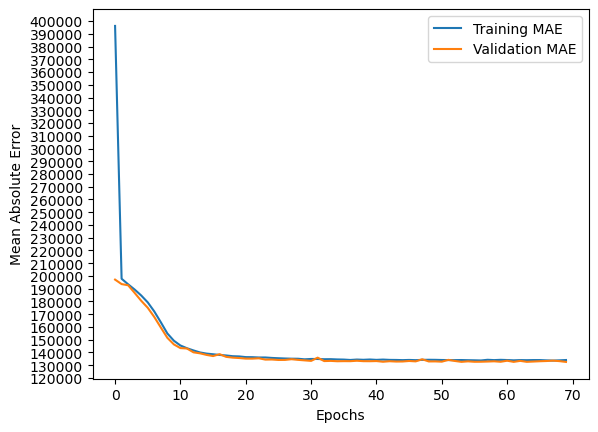

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model9 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.05),
    Dense(128, activation="relu"),
    Dropout(0.05),
    Dense(128, activation="relu"),
    Dropout(0.05),
    Dense(1)
])
model9.summary()
model9.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model9.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,313 (1.52 MB)

 Trainable params: 397,313 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 204892733440.0000 - mae: 365455.8125 - val_loss: 56923385856.0000 - val_mae: 194365.8906
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 56088190976.0000 - mae: 190839.6875 - val_loss: 50812788736.0000 - val_mae: 180992.1094
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 49579495424.0000 - mae: 178852.1562 - val_loss: 42602008576.0000 - val_mae: 165068.1562
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 40614211584.0000 - mae: 160545.7500 - val_loss: 36426043392.0000 - val_mae: 151371.9531
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 34555236352.0000 - mae: 146402.8438 - val_loss: 32601880576.0000 - val_mae: 141561.8750
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 32531183616.0000 - mae: 140453.7969 - val_loss: 32046383104.0000 - val_mae: 139475.8438
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 32446277632.0000 - mae: 140069.6250 - val_loss: 319

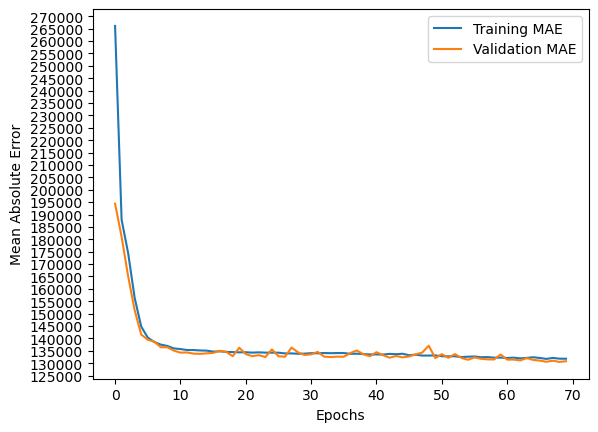

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model0 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.1),
    Dense(256, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model0.summary()
model0.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model0.fit(X_train, y_train, epochs=70, validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,897 (2.02 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 177770889216.0000 - mae: 336318.8750 - val_loss: 56520835072.0000 - val_mae: 194777.6094
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 53885718528.0000 - mae: 187125.3750 - val_loss: 48551292928.0000 - val_mae: 177417.7969
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 45521883136.0000 - mae: 170666.1562 - val_loss: 38155542528.0000 - val_mae: 155566.9844
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 35818061824.0000 - mae: 149252.0312 - val_loss: 32750891008.0000 - val_mae: 141718.7969
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 32819324928.0000 - mae: 140808.8281 - val_loss: 31213160448.0000 - val_mae: 137307.8750
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 31229235200.0000 - mae: 135992.2344 - val_loss: 31570325504.0000 - val_mae: 137503.0000
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 31214659584.0000 - mae: 136021.8281 - val_loss: 306

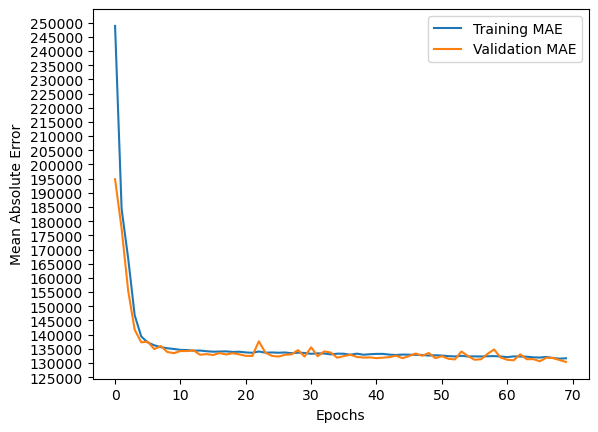

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model8 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model8.summary()
model8.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model8.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model1 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,409 (68.00 KB)

 Trainable params: 17,409 (68.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model1.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 313758744576.0000 - mae: 492451.1250 - val_loss: 301296254976.0000 - val_mae: 480474.2188
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 294870056960.0000 - mae: 473210.0312 - val_loss: 246173040640.0000 - val_mae: 421122.5938
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 223047385088.0000 - mae: 392667.8750 - val_loss: 138531061760.0000 - val_mae: 285560.0938
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 112233963520.0000 - mae: 252463.1094 - val_loss: 61592350720.0000 - val_mae: 197003.2812
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 61525057536.0000 - mae: 198411.3906 - val_loss: 59902930944.0000 - val_mae: 198181.8438
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 61597384704.0000 - mae: 200057.8594 - val_loss: 59305447424.0000 - val_mae: 196244.4375
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 60203065344.0000 - mae: 197709.9688 - val_los

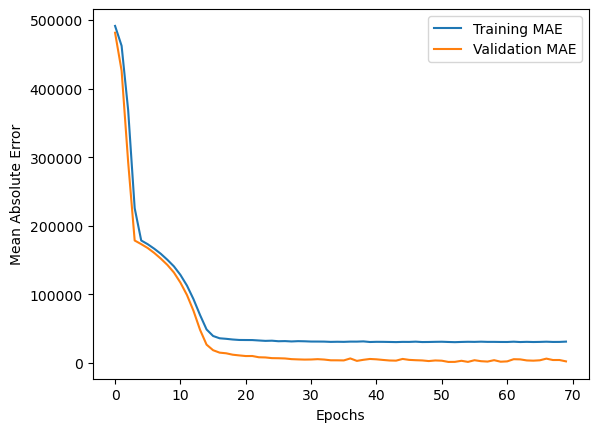

In [ ]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

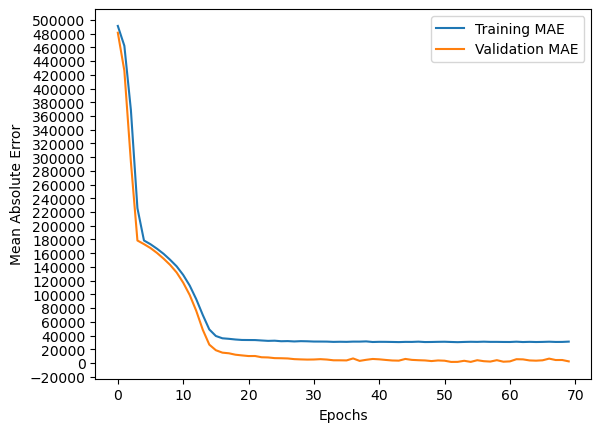

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model2 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model2.summary()
model2.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model2.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 311246487552.0000 - mae: 490131.3125 - val_loss: 257166901248.0000 - val_mae: 435246.4375
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 213220032512.0000 - mae: 383338.7500 - val_loss: 82442723328.0000 - val_mae: 214393.7812
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 67604451328.0000 - mae: 195257.8281 - val_loss: 47163727872.0000 - val_mae: 175248.7344
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 48366866432.0000 - mae: 177436.7344 - val_loss: 44546424832.0000 - val_mae: 171530.8281
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45548052480.0000 - mae: 172787.0938 - val_loss: 41744244736.0000 - val_mae: 166316.5000
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 42362355712.0000 - mae: 167502.4375 - val_loss: 38570823680.0000 - val_mae: 159689.5625
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 39531999232.0000 - mae: 161362.2812 - val_loss: 3

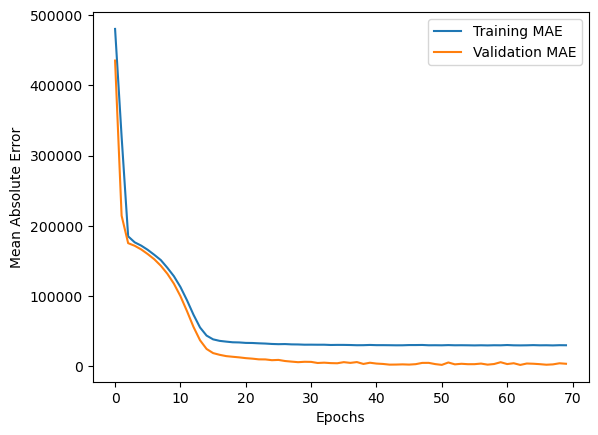

In [ ]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

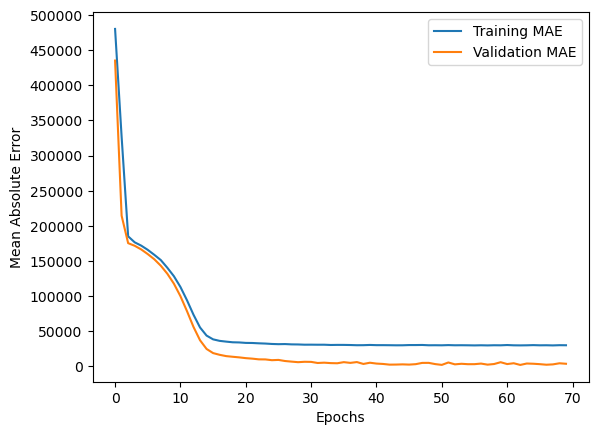

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.1),

    Dense(1)
])
model3.summary()
model3.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,729 (100.50 KB)

 Trainable params: 25,729 (100.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 253168156672.0000 - mae: 422984.0000 - val_loss: 44313104384.0000 - val_mae: 170776.2656
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 43333091328.0000 - mae: 168508.8125 - val_loss: 30683320320.0000 - val_mae: 143294.5625
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28100352000.0000 - mae: 135346.7344 - val_loss: 9918284800.0000 - val_mae: 80322.0781
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8643798016.0000 - mae: 72424.8359 - val_loss: 1043020224.0000 - val_mae: 25076.8184
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3392092672.0000 - mae: 43762.1641 - val_loss: 498666752.0000 - val_mae: 16245.5420
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2943779840.0000 - mae: 40157.9688 - val_loss: 272619424.0000 - val_mae: 11855.3145
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2736317696.0000 - mae: 38144.6680 - val_loss: 174895408.0000 - val_

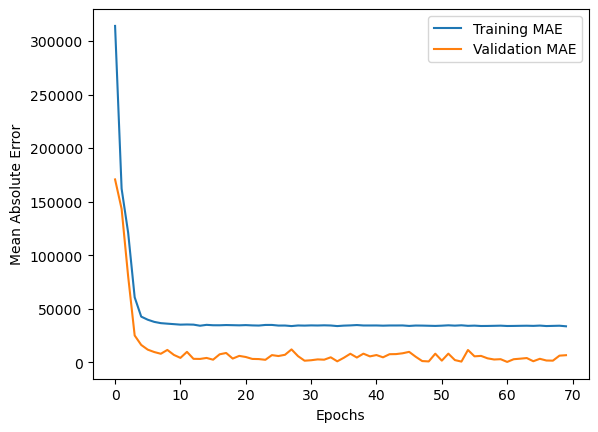

In [ ]:
history = model3.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

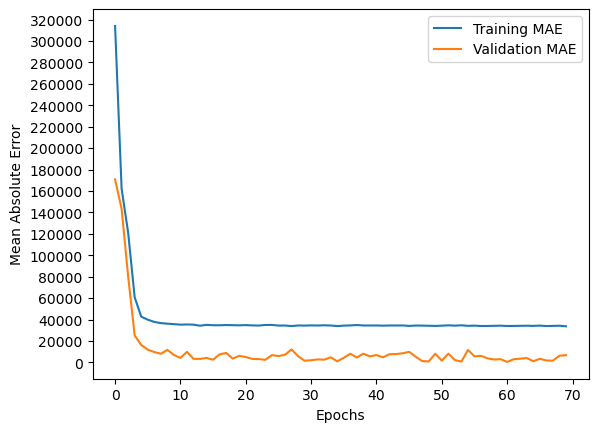

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model4 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(127, activation="relu"),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model4.summary()
model4.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 512)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 127)            │        32,639 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 127)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,808 (686.75 KB)

 Trainable params: 175,808 (686.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 161576763392.0000 - mae: 310071.5938 - val_loss: 2455998208.0000 - val_mae: 39417.3047
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3418927872.0000 - mae: 43941.2031 - val_loss: 197432368.0000 - val_mae: 10121.7715
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2432635392.0000 - mae: 36022.6445 - val_loss: 161022336.0000 - val_mae: 10636.0176
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2328605440.0000 - mae: 34537.3125 - val_loss: 49089676.0000 - val_mae: 5933.5195
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2151852800.0000 - mae: 33377.7383 - val_loss: 34687996.0000 - val_mae: 5033.5469
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2191398912.0000 - mae: 33432.2656 - val_loss: 42288340.0000 - val_mae: 5257.2871
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2201742336.0000 - mae: 33525.4336 - val_loss: 72240672.0000 - val_mae: 7992.0889
Epo

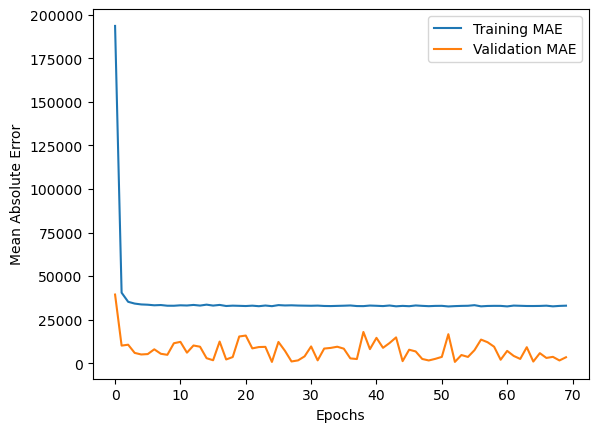

In [ ]:
history = model4.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

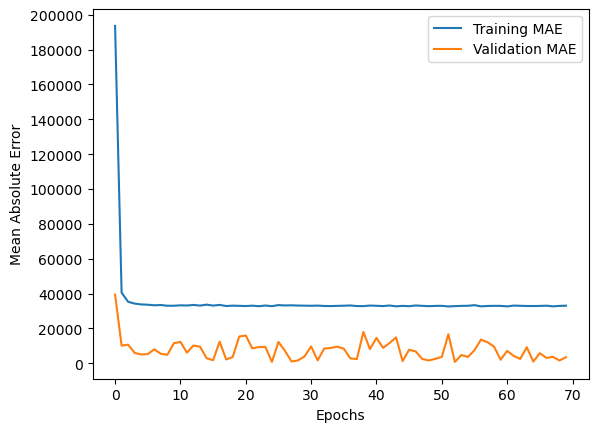

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model5 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(1)
])
model5.summary()
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,481 (455.00 KB)

 Trainable params: 116,481 (455.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 156843802624.0000 - mae: 302650.9375 - val_loss: 1450960896.0000 - val_mae: 31797.3848
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3717939456.0000 - mae: 44620.0391 - val_loss: 114073632.0000 - val_mae: 7954.5073
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3241386496.0000 - mae: 40732.9766 - val_loss: 128517040.0000 - val_mae: 9818.4385
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3144395520.0000 - mae: 40099.0469 - val_loss: 413705408.0000 - val_mae: 18348.4375
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3206246912.0000 - mae: 40017.0547 - val_loss: 333947488.0000 - val_mae: 17132.9707
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3246257152.0000 - mae: 40251.2734 - val_loss: 234619024.0000 - val_mae: 14634.3818
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3200743168.0000 - mae: 40196.6836 - val_loss: 210236272.0000 - val_mae: 13605.51

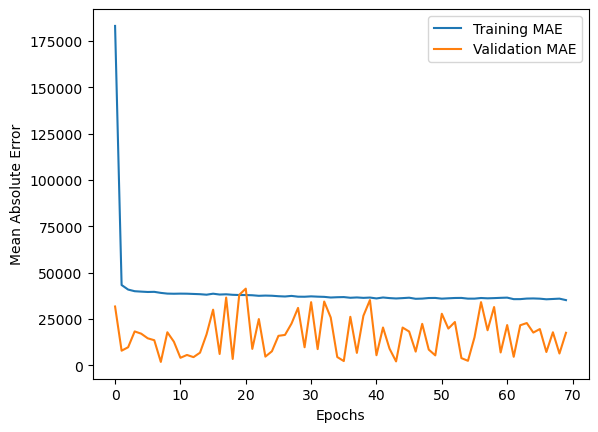

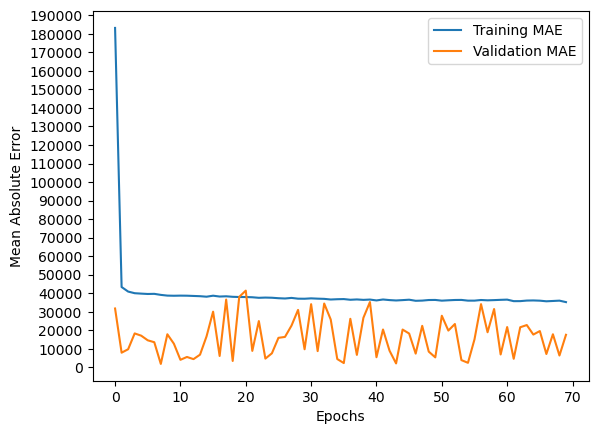

In [ ]:

history = model5.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 288940228608.0000 - mae: 463120.8125 - val_loss: 47204085760.0000 - val_mae: 175758.3281
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 46441402368.0000 - mae: 173988.3750 - val_loss: 31634018304.0000 - val_mae: 145541.9531
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28543356928.0000 - mae: 135715.8125 - val_loss: 5772562944.0000 - val_mae: 61391.3555
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5400960000.0000 - mae: 56171.1328 - val_loss: 443194400.0000 - val_mae: 15814.1934
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3003408128.0000 - mae: 39957.7930 - val_loss: 209425696.0000 - val_mae: 10739.4814
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2871689984.0000 - mae: 38580.1445 - val_loss: 89950552.0000 - val_mae: 6963.2974
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2737958400.0000 - mae: 37287.8672 - val_loss: 54283748.0000 - val_mae:

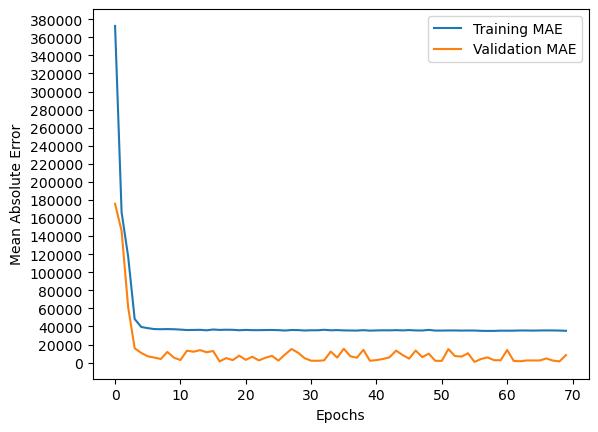

In [ ]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 286527815680.0000 - mae: 462121.5312 - val_loss: 48261300224.0000 - val_mae: 177194.3750
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 46732091392.0000 - mae: 175113.3906 - val_loss: 33274808320.0000 - val_mae: 148360.6875
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29198313472.0000 - mae: 138014.5312 - val_loss: 7298562560.0000 - val_mae: 69332.8281
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5406046208.0000 - mae: 56376.2461 - val_loss: 307305216.0000 - val_mae: 12752.1465
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2396591360.0000 - mae: 35465.0742 - val_loss: 144819728.0000 - val_mae: 8622.7881
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2139260288.0000 - mae: 33301.1367 - val_loss: 164434784.0000 - val_mae: 10538.5645
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2066020224.0000 - mae: 32537.3828 - val_loss: 111068488.0000 - val_ma

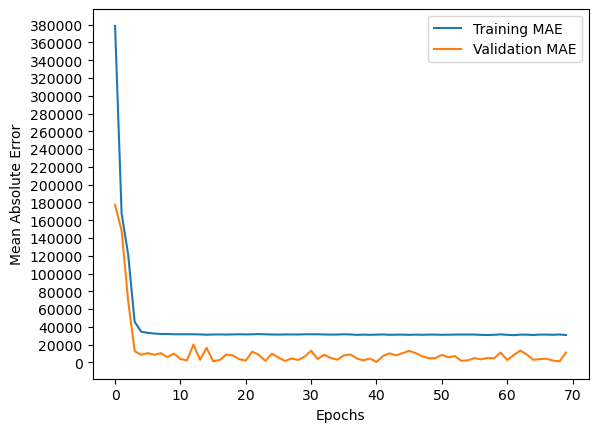

In [ ]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 311165386752.0000 - mae: 490558.8125 - val_loss: 301836533760.0000 - val_mae: 481279.2500
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 298074898432.0000 - mae: 477346.8125 - val_loss: 248172773376.0000 - val_mae: 425402.5312
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 225068875776.0000 - mae: 399150.5625 - val_loss: 140418433024.0000 - val_mae: 291955.0312
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 115248095232.0000 - mae: 259097.4688 - val_loss: 50840354816.0000 - val_mae: 177792.7656
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 48447348736.0000 - mae: 176361.3125 - val_loss: 45462183936.0000 - val_mae: 173643.1875
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45090250752.0000 - mae: 172975.5312 - val_loss: 42112827392.0000 - val_mae: 166931.3438
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 41223778304.0000 - mae: 165318.0469 - val_los

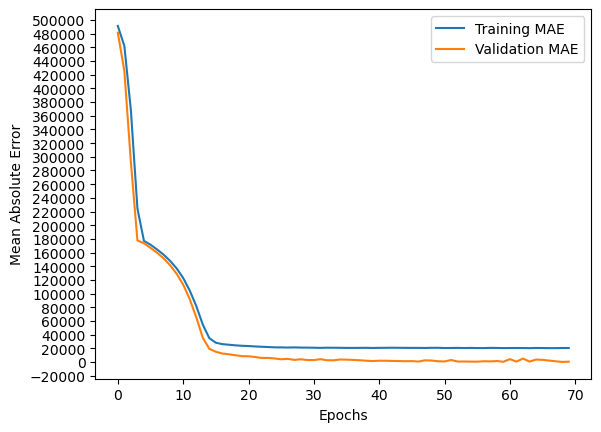

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model7 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model7.summary()
model7.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model7.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


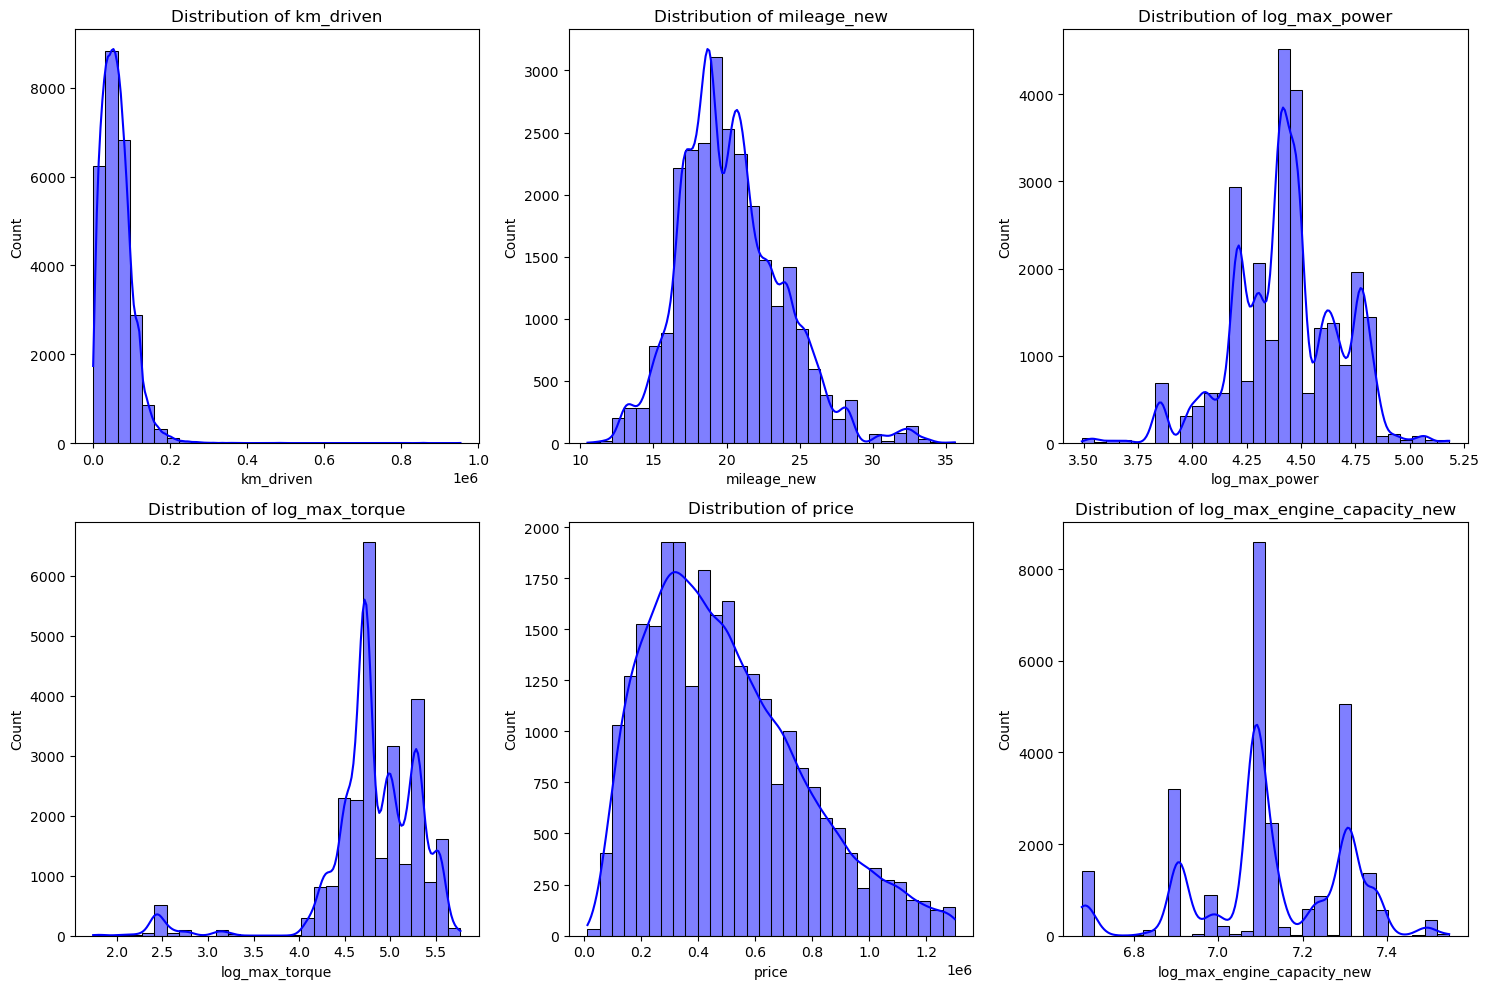

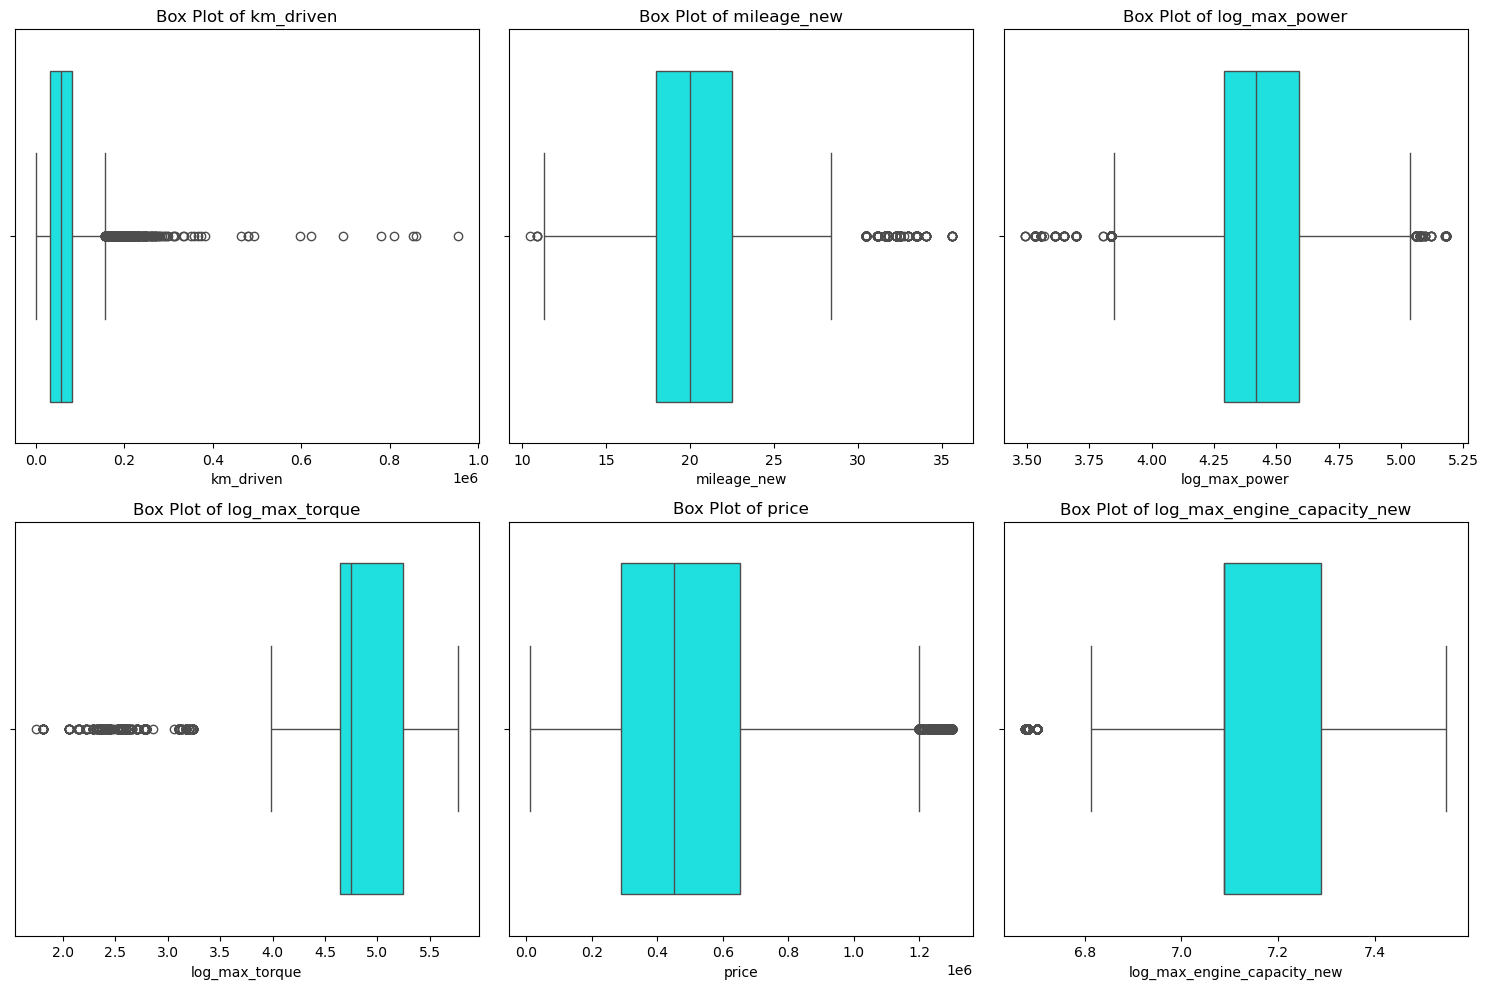

In [ ]:
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]



# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

Testing model with 3 hidden layers and 128 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 3, Neurons: 128, Train MSE: 4556533.00, Val MSE: 1854066.25
Testing model with 3 hidden layers and 180 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 3, Neurons: 180, Train MSE: 494475.44, Val MSE: 196255.41
Testing model with 3 hidden layers and 256 neurons


...

Layers: 5, Neurons: 128, Train MSE: 131345.61, Val MSE: 331460.19
Testing model with 5 hidden layers and 180 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 5, Neurons: 180, Train MSE: 206113.14, Val MSE: 140158.52
Testing model with 5 hidden layers and 256 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 5, Neurons: 256, Train MSE: 821109.12, Val MSE: 180510.58


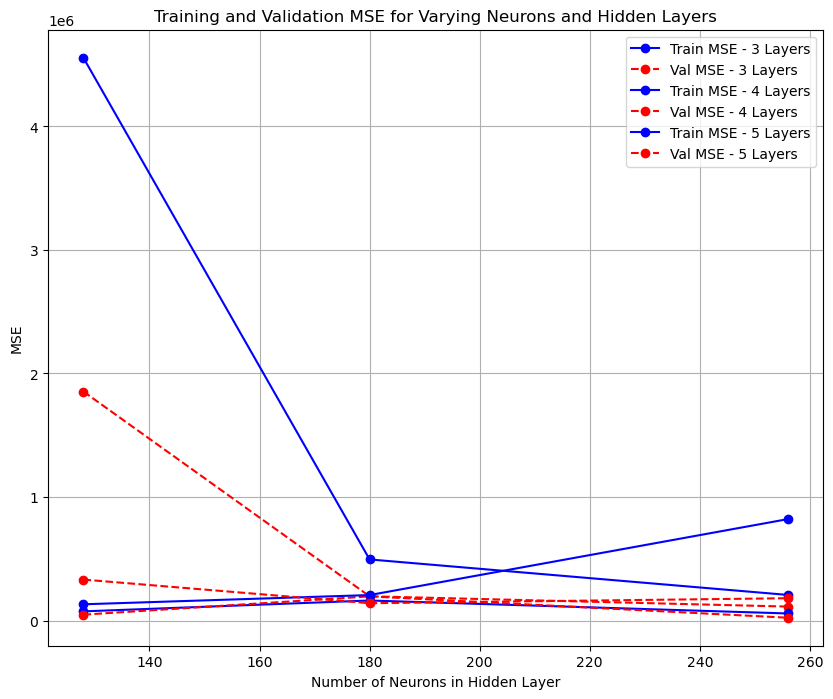

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define neuron configurations (4 different numbers of neurons)
neuron_no = [ 128, 180 , 256]  # Neurons
layer_no = [  3, 4,5,  ]  # Number of hidden layers

mse_train = {layers: [] for layers in layer_no}  # Store training MSE for each layer configuration
mse_val = {layers: [] for layers in layer_no}  # Store validation MSE for each layer configuration

# Loop over different numbers of hidden layers (1, 2, 3, 4 layers)
for layers in layer_no:
    for neurons in neuron_no:
        print(f"Testing model with {layers} hidden layers and {neurons} neurons")
        
        # Build the model with the specified number of hidden layers and neurons
        model = Sequential()
        model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))  # Input + 1st hidden layer
        for _ in range(layers - 1):  # Add additional hidden layers
            model.add(Dense(neurons, activation='relu'))
        model.add(Dense(1))  # Output layer for regression
        
        # Compile and train the model
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=0)

        # Store the MSE for both training and validation
        mse_train[layers].append(history.history['loss'][-1])  # Last epoch training MSE
        mse_val[layers].append(history.history['val_loss'][-1])  # Last epoch validation MSE
        print(f"Layers: {layers}, Neurons: {neurons}, Train MSE: {mse_train[layers][-1]:.2f}, Val MSE: {mse_val[layers][-1]:.2f}")

# Plot MSE for both training and validation for each configuration
plt.figure(figsize=(10, 8))

# Plot for each layer configuration
for layers in layer_no:
    plt.plot(neuron_no, mse_train[layers], marker='o', label=f'Train MSE - {layers} Layers', linestyle='-', color='blue')
    plt.plot(neuron_no, mse_val[layers], marker='o', label=f'Val MSE - {layers} Layers', linestyle='--', color='red')

plt.title("Training and Validation MSE for Varying Neurons and Hidden Layers")
plt.xlabel("Number of Neurons in Hidden Layer")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model10.save('trained_model.keras')